<a href="https://colab.research.google.com/github/2303A51553/HPC/blob/main/2303A51553_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab: NUMA Effects and Bandwidth Measurement

In [ ]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      2
  On-line CPU(s) list:       0,1
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:              6
    Model:                   79
    Thread(s) per core:      2
    Core(s) per socket:      1
    Socket(s):               1
    Stepping:                0
    BogoMIPS:                4399.99
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                   

In [ ]:
!apt-get update
!apt-get install -y numactl

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.0 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,769 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,301 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:

In [ ]:
!numactl --hardware


available: 1 nodes (0)
node 0 cpus: 0 1
node 0 size: 12975 MB
node 0 free: 8619 MB
node distances:
node   0 
  0:  10 


In [ ]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      2
  On-line CPU(s) list:       0,1
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:              6
    Model:                   79
    Thread(s) per core:      2
    Core(s) per socket:      1
    Socket(s):               1
    Stepping:                0
    BogoMIPS:                4399.99
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                   

#Assignment -2

In [1]:
import numpy as np
import time
N=100_000_000
a=np.ones(N,dtype=np.float64)
b=np.ones(N,dtype=np.float64)
start=time.time()
c=a+b;
end=time.time()
total_bytes = a.nbytes * 2 * 5
time_taken = end - start
bandwidth = total_bytes / time_taken / (1024**3)

print("Execution Time:", time_taken, "seconds")
print("Effective Bandwidth:", bandwidth, "GB/s")


Execution Time: 0.7795825004577637 seconds
Effective Bandwidth: 9.557141922181316 GB/s


3.Local vs Remote Memory Access Performance (NUMA-
Aware Execution)

In [9]:
for i in range(3):
    start = time.time()
    a *= 1.01
    print("Run", i+1, "Time:", time.time() - start)

Run 1 Time: 0.0872948169708252
Run 2 Time: 0.08250880241394043
Run 3 Time: 0.08361339569091797


4.Impact of Multi-threaded Memory Access on NUMA
Systems

In [10]:
import numpy as np
import threading
import time

size = 50_000_000
A = np.ones(size, dtype=np.float64)

def worker(start, end):
    A[start:end] *= 1.1

num_threads = 4
chunk = size // num_threads

threads = []
start_time = time.time()

for i in range(num_threads):
    t = threading.Thread(target=worker, args=(i*chunk, (i+1)*chunk))
    threads.append(t)
    t.start()

for t in threads:
    t.join()

end_time = time.time()

print("Execution Time:", end_time - start_time)

Execution Time: 0.036995649337768555


5.Comparative Study of NUMA-Unaware vs NUMA-Aware
Execution

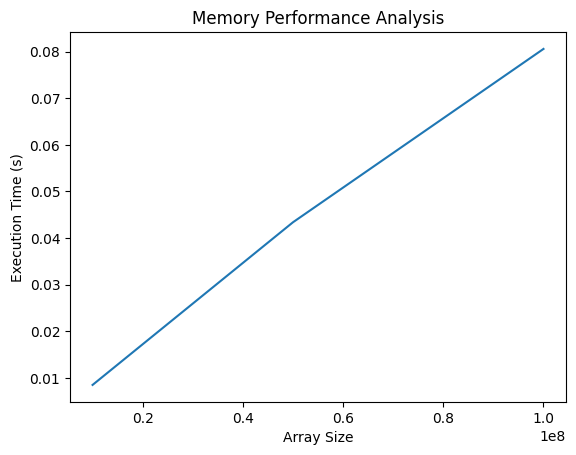

In [11]:
import matplotlib.pyplot as plt

sizes = [10_000_000, 50_000_000, 100_000_000]
times = []

for size in sizes:
    A = np.ones(size)
    start = time.time()
    A *= 1.1
    times.append(time.time() - start)

plt.plot(sizes, times)
plt.xlabel("Array Size")
plt.ylabel("Execution Time (s)")
plt.title("Memory Performance Analysis")
plt.show()